In [178]:
import pandas as pd
from scvi.model import SCANVI
import anndata as ad
from anndata import read_zarr
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import scanpy.external as sce
import scvi
import torch

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: nb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False


Grabbing the first 2 processed datasets

In [179]:
GaldosPath = "../rawFileProcess/ProcessedData/GaldosScanpy.zarr"
ProdzynskiPath = "../rawFileProcess/ProcessedData/ProdzynskiScanpy.zarr"

GaldosAdata = ad.read_zarr(GaldosPath)
ProdAdata = ad.read_zarr(ProdzynskiPath)


SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: nb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False


In [180]:
mergedAdata = ad.concat([GaldosAdata, ProdAdata], join = "inner")

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: nb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False


remove these Anndata object to save memory

In [181]:
del GaldosAdata
del ProdAdata

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: nb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False


Adding in final dataset

In [182]:
KanemaruPath = "../rawFileProcess/ProcessedData/KanemaruScanpy.zarr"
KanemaruAdata = ad.read_zarr(KanemaruPath)

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: nb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False


In [183]:
mergedAdata = ad.concat([mergedAdata, KanemaruAdata], join = "inner")

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: nb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False


In [184]:
del KanemaruAdata

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: nb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False


Filtering the genes to only contain the most variable across, saving memory and removing genes that aren't necessarily relavent or important

In [185]:
sc.pp.highly_variable_genes(
    mergedAdata,
    n_top_genes = 1500,
    batch_key = "batch",
    subset = True,
)

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: nb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False


This is the AI model that handles batch effects. It also replaces running PCA, and creates its own latent space/reduced dimensionality. Massive pain to deal with, very touchy. The main issue is that batch effect algorithms work by finding cells that are similar across different batches and then "pushing" them together. The issue is that there are no similar cells in batches from adult tissue, and iPSCs. This leads to a balancing act of trying to minimize any batch effects, while preserving some level of uniqueness of the adult tissue and iPSCs. It also can take a while to run. Ideally, you want a graphics card with CUDA cores. I have run this on both my laptop with an RTX A2000 with 8gb vRAM (took 4-6 minutes), and our lab's computer, which has an RTX 4090 with 24gb VRAM (took like 1 minute).

In [218]:
scvi.model.SCVI.setup_anndata(mergedAdata, layer = "counts", batch_key="batch",
continuous_covariate_keys = ["pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
)
model = scvi.model.SCVI(mergedAdata, gene_likelihood = "nb",
n_latent=20,
)
model.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/kai/Documents/SCTLM-Bridges/.venv/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/kai/Documents/SCTLM-Bridges/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 156/156: 100%|██████████| 156/156 [04:10<00:00,  1.61s/it, v_num=1, train_loss=939]

`Trainer.fit` stopped: `max_epochs=156` reached.


Epoch 156/156: 100%|██████████| 156/156 [04:10<00:00,  1.61s/it, v_num=1, train_loss=939]
SCVI model with the following parameters: 
n_hidden: 128, n_latent: 20, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: nb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False


Grabbing the latent space made, and then running nearest neighbors, clustering, and umap with that, for dimension reduction, and visualization.

In [219]:
SCVI_LATENT_KEY = "X_scVI"
mergedAdata.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()
mergedAdata.layers["SCVI_normalized"] = model.get_normalized_expression()

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 20, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: nb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False


In [220]:
sc.pp.neighbors(mergedAdata, use_rep=SCVI_LATENT_KEY)
sc.tl.leiden(mergedAdata, resolution = 0.1)

sc.tl.umap(mergedAdata)


<positron-console-cell-220>:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.


SCVI model with the following parameters: 
n_hidden: 128, n_latent: 20, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: nb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False


Brief check on clustering based on days

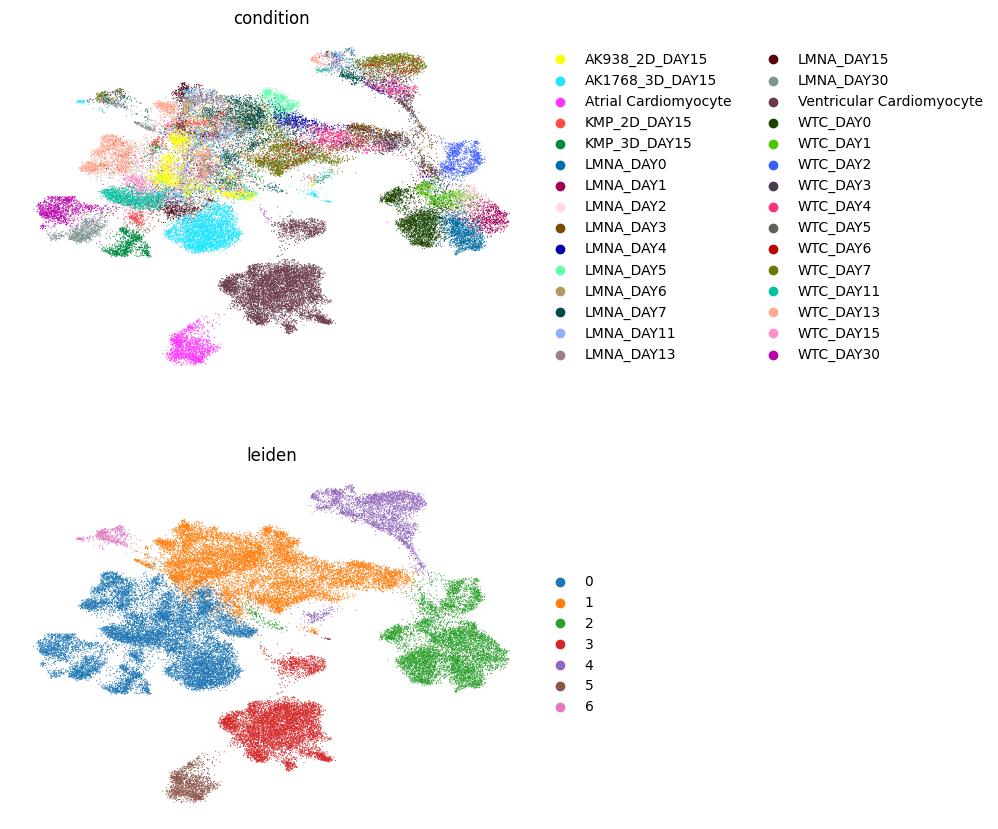

<bound method AnnData.obs_keys of AnnData object with n_obs × n_vars = 51370 × 1500
    obs: 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'batch', 'n_genes', 'Day', 'source', 'system', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'leiden', 'umap', 'Day_colors', 'condition_colors', 'leiden_colors'
    obsm: '_scvi_extra_continuous_covs', 'X_scVI', 'X_umap'
    layers: 'counts', 'SCVI_normalized'
    obsp: 'distances', 'connectivities'>
SCVI model with the following parameters: 
n_hidden: 128, n_latent: 20, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene

In [221]:
sc.pl.umap(
    mergedAdata,
    color=["condition", "leiden"],
    frameon=False,
    ncols=1,
)
print(mergedAdata.obs_keys)

Saving to file

In [222]:
mergedAdata.write_zarr("Integrated.zarr")

/home/kai/Documents/SCTLM-Bridges/.venv/lib/python3.14/site-packages/anndata/_io/zarr.py:44: UserWarning: Writing zarr v2 data will no longer be the default in the next minor release. v3 data will be written by default. If you are explicitly setting this configuration, consider migrating to the zarr v3 file format.
  f = open_write_group(store)


SCVI model with the following parameters: 
n_hidden: 128, n_latent: 20, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: nb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False
